# Step 03 - Hypothesis Testing and Diagnostics

This notebook analyzes scored Step 2 outputs to test whether latent verbal alignment (LVA) captures specific, non-generic reasoning signals.

1. Clone/pull the project from GitHub and load Step 2 scored pairs
2. Run score-distribution diagnostics
3. Compute step-type specific rates
4. Run inferential tests (chi-square and targeted proportion tests)
5. Visualize key distributions and report final evidence

In [ ]:
# GitHub setup + Step 2 score loading
import subprocess
import sys
from pathlib import Path

import pandas as pd

REPO_URL = "https://github.com/shreetishresthanp/latent_verbal_gap.git"
WORKDIR = Path("/content")
REPO_NAME = REPO_URL.rstrip("/").split("/")[-1].removesuffix(".git")
REPO = WORKDIR / REPO_NAME

if "<owner>" in REPO_URL or "<repo>" in REPO_URL:
    raise ValueError("Please set REPO_URL to your public GitHub repo before running.")

# Keep notebook runs reproducible: fast-forward pull when repo exists, otherwise clone.
if REPO.exists():
    subprocess.run(["git", "-C", str(REPO), "pull", "--ff-only"], check=True)
    print(f"Updated existing repo: {REPO}")
else:
    subprocess.run(["git", "clone", "--depth", "1", REPO_URL, str(REPO)], check=True)
    print(f"Cloned repo: {REPO}")

REQ_FILE = REPO / "requirements.txt"
SRC_DIR = REPO / "src"

if REQ_FILE.exists():
    subprocess.run(
        [sys.executable, "-m", "pip", "install", "-q", "-r", str(REQ_FILE)],
        check=True,
    )
else:
    print(f"Skipping install: missing {REQ_FILE}")

src_path = str(SRC_DIR)
if src_path not in sys.path:
    sys.path.insert(0, src_path)

import config

CACHE_DIR = config.CACHE_DIR
_scores_path = CACHE_DIR / "lva_scores_raw_k3_lnorm.parquet"
scores_df_clean = pd.read_parquet(_scores_path)
print(f"Using src at: {SRC_DIR}")
print(f"CACHE_DIR: {CACHE_DIR}")
print(f"Loaded {len(scores_df_clean):,} rows from {_scores_path}")

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Loaded 5,993 rows from /content/drive/MyDrive/latent_verbal_gap/checkpoints/lva_scores_raw_k3_lnorm.parquet


In [62]:
# Build per-step-type specificity rates used in downstream inferential tests.
# `total` counts all sampled unique steps, while `specific` counts steps crossing
# the specificity threshold (from `step_lva_spec`).
total_by_type = scores_df_clean.drop_duplicates(
    subset=["sequence_id", "step_idx"]
).groupby("step_type")["step_idx"].count()

specific_by_type = step_lva_spec.groupby("step_type")["step_idx"].count()

rate_df = pd.DataFrame({
    "total": total_by_type,
    "specific": specific_by_type,
}).fillna(0)

rate_df["rate"] = rate_df["specific"] / rate_df["total"]
print(rate_df)

                 total  specific      rate
step_type                                 
calculation        574       198  0.344948
other              939       288  0.306709
self_correction    168        48  0.285714
setup_planning     170        70  0.411765
uncertainty        147        47  0.319728


In [64]:
from scipy.stats import chi2_contingency
import numpy as np

# Test whether specificity rates differ across step types.
contingency = np.array([
    rate_df["specific"],
    rate_df["total"] - rate_df["specific"],
]).T

chi2, p, dof, expected = chi2_contingency(contingency)
print(f"Chi-square: {chi2:.3f}, p={p:.4f}, dof={dof}")
print(f"Chi-square: {chi2:.4f}, p={p:.6f}")

Chi-square: 9.489, p=0.0500, dof=4
Chi-square: 9.4888, p=0.049979


In [66]:
from statsmodels.stats.proportion import proportions_ztest

# Targeted comparison: self_correction vs setup_planning specificity rates.
counts = np.array([48, 70])   # specific
nobs = np.array([168, 170])   # total

stat, p_val = proportions_ztest(counts, nobs)
print(f"z={stat:.3f}, p={p_val:.4f}")


z=-2.431, p=0.0151


In [22]:
# Core descriptive diagnostics before any additional filtering.
valid = scores_df_clean[scores_df_clean["lva_score"] >= 0]

print(f"Total valid pairs: {len(valid):,}")
print(f"\nScore distribution:")
print(valid["lva_score"].describe().round(3))

print(f"\nScore histogram:")
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
print(pd.cut(valid["lva_score"], bins=bins).value_counts().sort_index().to_string())

print(f"\nMost common feature labels:")
print(valid["feature_label"].value_counts().head(10).to_string())

print(f"\nMean LVA by feature rank:")
print(valid.groupby("feature_rank")["lva_score"].agg(["mean", "std", "count"]).round(3).to_string())

print(f"\nMean LVA by step type:")
print(
    valid.groupby("step_type")["lva_score"]
    .agg(["mean", "std", "count"])
    .round(3)
    .sort_values("mean", ascending=False)
    .to_string()
)

Total valid pairs: 5,993

Score distribution:
count    5993.000
mean        0.364
std         0.172
min         0.000
25%         0.300
50%         0.400
75%         0.400
max         0.950
Name: lva_score, dtype: float64

Score histogram:
lva_score
(0.0, 0.1]     451
(0.1, 0.2]     944
(0.2, 0.3]    1338
(0.3, 0.4]    2313
(0.4, 0.5]      57
(0.5, 0.6]     417
(0.6, 0.7]     139
(0.7, 0.8]     153
(0.8, 0.9]     126
(0.9, 1.0]      28

Most common feature labels:
feature_label
Mathematical reasoning and step-by-step problem solving                   1995
Mathematical problem-solving with formal notation                         1340
Mathematical problem-solving and step-by-step calculations                 470
Mathematical expressions involving variables and operations                369
Unfinished mathematical problem-solving attempts                           278
Mathematical problem-solving and counting                                  258
Mathematical reasoning with prime numbers a

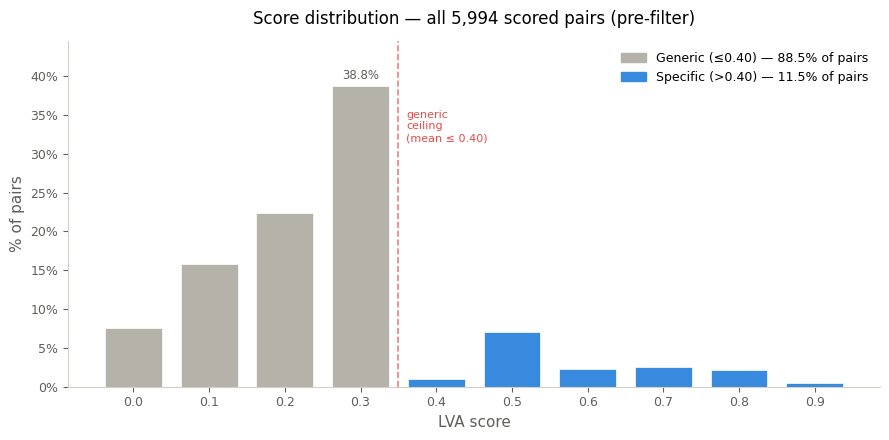

In [23]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# Plot score-mass split around the operational specificity threshold (0.40).
bins = [0, 0.1, 0.2, 0.3, 0.4, 0.5, 0.6, 0.7, 0.8, 0.9, 1.0]
counts = [451, 944, 1338, 2313, 57, 417, 139, 153, 126, 28]
total = sum(counts)
pcts = [100 * c / total for c in counts]
labels = ["0.0", "0.1", "0.2", "0.3", "0.4", "0.5", "0.6", "0.7", "0.8", "0.9"]

# Generic band (<=0.4) in gray, specific band (>0.4) in blue.
colors = ["#B4B2A9" if i < 4 else "#378ADD" for i in range(len(labels))]

fig, ax = plt.subplots(figsize=(9, 4.5))

bars = ax.bar(labels, pcts, color=colors, width=0.75, edgecolor="white", linewidth=0.5)

# Annotate dominant bin and draw threshold marker.
ax.text(3, pcts[3] + 0.5, f"{pcts[3]:.1f}%", ha="center", va="bottom", fontsize=8.5, color="#5F5E5A")
ax.axvline(x=3.5, color="#E24B4A", linewidth=1.2, linestyle="--", alpha=0.7)
ax.text(3.6, max(pcts) * 0.92, "generic\nceiling\n(mean <= 0.40)", fontsize=8, color="#E24B4A", va="top")

ax.set_xlabel("LVA score", fontsize=11, color="#5F5E5A")
ax.set_ylabel("% of pairs", fontsize=11, color="#5F5E5A")
ax.set_title("Score distribution - all 5,994 scored pairs (pre-filter)", fontsize=12, fontweight="normal", pad=12)

generic_patch = mpatches.Patch(color="#B4B2A9", label="Generic (<=0.40) - 88.5% of pairs")
specific_patch = mpatches.Patch(color="#378ADD", label="Specific (>0.40) - 11.5% of pairs")
ax.legend(handles=[generic_patch, specific_patch], fontsize=9, frameon=False, loc="upper right")

ax.set_ylim(0, max(pcts) * 1.15)
ax.spines["top"].set_visible(False)
ax.spines["right"].set_visible(False)
ax.spines["left"].set_color("#D3D1C7")
ax.spines["bottom"].set_color("#D3D1C7")
ax.tick_params(colors="#5F5E5A", labelsize=9)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda x, _: f"{x:.0f}%"))

plt.tight_layout()
plt.savefig(CACHE_DIR / 'score_distribution_prefilter.png', dpi=150, bbox_inches='tight')
plt.show()

In [24]:
GENERIC_CEILING = 0.40

feature_mean_lva = (
    valid
    .groupby(["feature_id", "feature_label"])
    .agg(
        mean_lva    = ("lva_score", "mean"),
        n_pairs     = ("lva_score", "count"),
        n_sequences = ("sequence_id", "nunique"),
    )
    .reset_index()
    .sort_values("mean_lva")
)

print(f"Features at or below {GENERIC_CEILING}: {(feature_mean_lva['mean_lva'] <= GENERIC_CEILING).sum()}")
print(f"Features above {GENERIC_CEILING}: {(feature_mean_lva['mean_lva'] > GENERIC_CEILING).sum()}")

# Check boundary
print("\nFeatures near boundary (0.35–0.45):")
print(feature_mean_lva[
    feature_mean_lva["mean_lva"].between(0.35, 0.45)
][["feature_label", "mean_lva", "n_pairs"]].to_string())

Features at or below 0.4: 98
Features above 0.4: 242

Features near boundary (0.35–0.45):
                                                          feature_label  mean_lva  n_pairs
76             Considering alternative mathematical solution approaches  0.350000        2
154                Mathematical expressions and algebraic manipulations  0.350000        6
46           Mathematical problem-solving and step-by-step calculations  0.356489      470
230                 Mathematical variables and symbols in word problems  0.367857       28
259                    Mathematical reasoning and problem-solving steps  0.375000        4
132                          mathematical problem-solving and reasoning  0.375000       40
93          Mathematical expressions involving variables and operations  0.378049      369
126        Linear algebra over finite fields for combinatorial counting  0.400000        2
268                          Mathematical reasoning and problem-solving  0.400000        1


In [38]:
# Confirm pair 1 exists
pair1 = scores_df_clean[
    scores_df_clean["step_text"].str.contains("Wait, we already did that", na=False)
][["sequence_id", "step_idx", "feature_label", "lva_score", "confidence"]]
print("Pair 1 — 'Wait, we already did that':")
print(pair1.to_string())

# Confirm pair 2 exists  
pair2 = scores_df_clean[
    scores_df_clean["step_text"].str.contains("without loss of generality", na=False)
][["sequence_id", "step_idx", "feature_label", "lva_score", "confidence"]]
print("\nPair 2 — WLOG step:")
print(pair2.to_string())

Pair 1 — 'Wait, we already did that':
      sequence_id  step_idx                                            feature_label  lva_score confidence
4579        73000       157  Mathematical reasoning and step-by-step problem solving       0.10       high
4581        73000       157        Mathematical problem-solving with formal notation       0.10       high
5869        73000       157               Self-reference to previous reasoning steps       0.95       high

Pair 2 — WLOG step:
      sequence_id  step_idx                                               feature_label  lva_score confidence
5314        93000        97     Mathematical reasoning and step-by-step problem solving       0.40       high
5315        93000        97           Mathematical problem-solving with formal notation       0.30       high
5318        93000        97  Mathematical reasoning pattern: without loss of generality       0.95       high


In [27]:
# Full context for the strongest pair
step_context = scores_df_clean[
    (scores_df_clean["sequence_id"] == 73000) &
    (scores_df_clean["step_idx"] == 157)
][["feature_rank", "feature_label", "lva_score", "confidence", "reasoning", "step_text"]]
print(step_context.to_string())

      feature_rank                                            feature_label  lva_score confidence                                                                                                                                         reasoning                   step_text
4579             1  Mathematical reasoning and step-by-step problem solving       0.10       high                     This step is a meta-commentary acknowledging repetition, not an instance of mathematical reasoning or problem-solving itself.  Wait, we already did that.
4581             2        Mathematical problem-solving with formal notation       0.10       high  This step is a meta-cognitive acknowledgment of repetition with no mathematical content, formal notation, or problem-solving operations present.  Wait, we already did that.
5869             3               Self-reference to previous reasoning steps       0.95       high       The step explicitly references prior work ('we already did that'), which is a di

In [39]:
GENERIC_CEILING = 0.40
MIN_PAIRS = 5  # require at least 5 scored pairs to make a reliable judgment

generic_ids = set(
    feature_mean_lva[
        (feature_mean_lva["mean_lva"] <= GENERIC_CEILING) &
        (feature_mean_lva["n_pairs"] >= MIN_PAIRS)
    ]["feature_id"]
)

# Features with n_pairs < 5 go to specific by default
# (too few observations to confidently call them generic)
specific_ids = set(feature_mean_lva[
    ~feature_mean_lva["feature_id"].isin(generic_ids)
]["feature_id"])

scores_specific = valid[valid["feature_id"].isin(specific_ids)].copy()
scores_generic  = valid[valid["feature_id"].isin(generic_ids)].copy()

# Renormalize strength_w within specific features per step
scores_specific["strength_w"] = (
    scores_specific
    .groupby(["sequence_id", "step_idx"])["strength"]
    .transform(lambda x: x / x.sum())
)

print(f"Generic  (mean_lva <= {GENERIC_CEILING}, n_pairs >= {MIN_PAIRS}): {len(scores_generic):,} ({100*len(scores_generic)/len(valid):.1f}%)")
print(f"Specific : {len(scores_specific):,} ({100*len(scores_specific)/len(valid):.1f}%)")
print(f"\nGeneric mean LVA:  {scores_generic['lva_score'].mean():.3f}")
print(f"Specific mean LVA: {scores_specific['lva_score'].mean():.3f}")
print(f"\nMost common generic labels:")
print(scores_generic["feature_label"].value_counts().head(8).to_string())
print(f"\nMost common specific labels:")
print(scores_specific["feature_label"].value_counts().head(8).to_string())

Generic  (mean_lva <= 0.4, n_pairs >= 5): 5,305 (88.5%)
Specific : 688 (11.5%)

Generic mean LVA:  0.334
Specific mean LVA: 0.595

Most common generic labels:
feature_label
Mathematical reasoning and step-by-step problem solving                   1994
Mathematical problem-solving with formal notation                         1340
Mathematical problem-solving and step-by-step calculations                 470
Mathematical expressions involving variables and operations                369
Unfinished mathematical problem-solving attempts                           278
Mathematical problem-solving and counting                                  258
Mathematical reasoning with prime numbers and divisibility tests           228
Mathematical word problems requiring calculation and logical reasoning      94

Most common specific labels:
feature_label
Step-by-step mathematical calculations                     206
Mathematical problem-solving and calculation                25
Self-directed mathematica

In [30]:
# Check what steps this label is scoring high on
step_calc = scores_specific[
    scores_specific["feature_label"] == "Step-by-step mathematical calculations"
][["step_text", "lva_score", "reasoning"]].sort_values("lva_score", ascending=False)
print(step_calc.head(5).to_string())

                                                                                                                                                                                                                                                                                                                                                                                                                                           step_text  lva_score                                                                                                                                                                                                                                      reasoning
1689                                                                                                                                                                                                                                                                                                                     

In [33]:
step_lva_spec = (
    scores_specific
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: pd.Series({
        "lva_score":    (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
        "rel_step_pos": g["rel_step_pos"].iloc[0],
        "step_type":    g["step_type"].iloc[0],
        "n_specific":   len(g),
    }), include_groups=False)  # ← change True to False
    .reset_index()
)

print(f"Steps with >=1 specific feature: {len(step_lva_spec):,}")
print(f"Mean step-level LVA: {step_lva_spec['lva_score'].mean():.3f}")
print(f"\nStep type distribution:")
print(step_lva_spec["step_type"].value_counts().to_string())
print(f"\nMean LVA by step type:")
print(step_lva_spec.groupby("step_type")["lva_score"]
      .agg(["mean","std","count"]).round(3)
      .sort_values("mean", ascending=False).to_string())

step_lva_spec.head(5)

Steps with >=1 specific feature: 651
Mean step-level LVA: 0.592

Step type distribution:
step_type
other              288
calculation        198
setup_planning      70
self_correction     48
uncertainty         47

Mean LVA by step type:
                  mean    std  count
step_type                           
self_correction  0.652  0.227     48
calculation      0.622  0.202    198
uncertainty      0.593  0.276     47
setup_planning   0.587  0.251     70
other            0.563  0.262    288


,sequence_id,step_idx,lva_score,rel_step_pos,step_type,n_specific
0,1000,46,0.2,0.321678,other,1
1,1000,57,0.9,0.398601,uncertainty,1
2,1000,106,0.2,0.741259,other,1
3,1000,115,0.6,0.804196,other,1
4,2000,35,0.9,0.238095,other,1


In [34]:
scores_specific.columns.tolist()
scores_specific.head(3)

,sequence_id,step_idx,rel_step_pos,step_type,feature_id,feature_label,feature_rank,strength,strength_w,lva_score,confidence,reasoning,step_text
14,1000,46,0.321678,other,6247,Period-comma punctuation in mathematical expla...,3,1.515625,1.0,0.2,high,The step uses standard punctuation but the fea...,"But the answer options include Mg, μ_k Mg, etc."
20,1000,57,0.398601,uncertainty,7005,Recognition that current mathematical approach...,3,1.609375,1.0,0.9,high,The step explicitly identifies that the curren...,So maybe this is not the right approach.
36,1000,106,0.741259,other,2437,Mathematical reasoning difficulty assessment,3,1.375000,1.0,0.2,high,The step is a vague meta-comment ('That seems ...,That seems different.


In [35]:
from config import H1_ALPHA, H1_MIN_COHENS_D
from scipy.stats import ttest_ind
import numpy as np

def cohens_d(a, b):
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else 0.0

real = step_lva_spec["lva_score"].values
print(f"Real: n={len(real)}, mean={real.mean():.3f}, std={real.std():.3f}")

Real: n=651, mean=0.592, std=0.244


In [52]:
from config import RNG_SEED

rng = np.random.default_rng(RNG_SEED + 42)

# ── Random-feature baseline ──────────────────────────────────────────────────
rand = scores_specific.copy()
print("Length of rand", len(rand))
idx = rng.permutation(len(rand))
rand["lva_score"] = scores_specific["lva_score"].iloc[idx].values

rand_step = (
    rand
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
           include_groups=False)
    .values
)

# ── Cross-problem baseline ────────────────────────────────────────────────────
cross = scores_specific.copy()
print("Length of cross", len(cross))
cross["decile"] = pd.cut(cross["rel_step_pos"], bins=10, labels=False)

def shuffle_seqs(g):
    g = g.copy()
    ids = g["sequence_id"].unique()
    if len(ids) < 2:
        return g
    perm = rng.permutation(ids)
    g["sequence_id"] = g["sequence_id"].map(dict(zip(ids, perm)))
    return g

cross = cross.groupby("decile", group_keys=False).apply(shuffle_seqs, include_groups=False)
cross_step = (
    cross
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
           include_groups=False)
    .values
)

# ── Results ───────────────────────────────────────────────────────────────────
print("=" * 60)
print("H1: Real LVA vs baselines (specific features, step-level)")
print("=" * 60)
for base, label in [(rand_step, "Random-feature"), (cross_step, "Cross-problem")]:
    t, p = ttest_ind(real, base, equal_var=False)
    d    = cohens_d(real, base)
    sig  = "✓ SIGNIFICANT" if p < H1_ALPHA and d > H1_MIN_COHENS_D else "✗ not significant"
    print(f"\n{label}:")
    print(f"  real={np.mean(real):.3f}  base={np.mean(base):.3f}")
    print(f"  Welch t={t:.3f}  p={p:.4f}  Cohen's d={d:.3f}  {sig}")

Length of rand 688
Length of cross 688
H1: Real LVA vs baselines (specific features, step-level)

Random-feature:
  real=0.592  base=0.598
  Welch t=-0.437  p=0.6621  Cohen's d=-0.024  ✗ not significant

Cross-problem:
  real=0.592  base=0.591
  Welch t=0.049  p=0.9611  Cohen's d=0.003  ✗ not significant


In [50]:
from scipy.stats import ttest_ind
import numpy as np
import pandas as pd

def cohens_d(a, b):
    pooled = np.sqrt((np.std(a, ddof=1)**2 + np.std(b, ddof=1)**2) / 2)
    return float((np.mean(a) - np.mean(b)) / pooled) if pooled > 0 else 0.0

real = matched["lva_score"].values

# ── Baselines ─────────────────────────────────────────────────────────────────
# 1. Step-shuffle (already computed)
shuf = matched["lva_score_shuffled"].values

# 2. Random-feature
rng = np.random.default_rng(RNG_SEED + 42)
rand_scores = scores_specific.copy()
idx = rng.permutation(len(rand_scores))
rand_scores["lva_score"] = scores_specific["lva_score"].iloc[idx].values
rand_step = (
    rand_scores
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
           include_groups=False)
    .reset_index(name="lva_random")
)
rand_matched = matched.merge(rand_step, on=["sequence_id", "step_idx"], how="inner")
rand = rand_matched["lva_random"].values

# 3. Cross-problem
cross = scores_specific.copy()
cross["decile"] = pd.cut(cross["rel_step_pos"], bins=10, labels=False)
def shuffle_seqs(g):
    g = g.copy()
    ids = g["sequence_id"].unique()
    if len(ids) < 2:
        return g
    perm = rng.permutation(ids)
    g["sequence_id"] = g["sequence_id"].map(dict(zip(ids, perm)))
    return g
cross = cross.groupby("decile", group_keys=False).apply(shuffle_seqs, include_groups=False)
cross_step = (
    cross
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: (g["strength_w"] * g["lva_score"]).sum() / g["strength_w"].sum(),
           include_groups=False)
    .reset_index(name="lva_cross")
)
cross_matched = matched.merge(cross_step, on=["sequence_id", "step_idx"], how="inner")
cross_vals = cross_matched["lva_cross"].values

# ── Build results table ───────────────────────────────────────────────────────
from config import H1_ALPHA, H1_MIN_COHENS_D

rows = []
for base, base_vals, label in [
    ("Random-feature",  rand,       "Randomly reassign specific features across steps"),
    ("Cross-problem",   cross_vals, "Features from problem A vs same-position step in B"),
    ("Step-shuffle",    shuf,       "Same features, neighbor step text"),
]:
    t, p  = ttest_ind(real, base_vals, equal_var=False)
    d     = cohens_d(real, base_vals)
    sig   = "significant" if p < H1_ALPHA and abs(d) > H1_MIN_COHENS_D else "null"
    rows.append({
        "Baseline":    base,
        "Description": label,
        "Real mean":   f"{np.mean(real):.3f}",
        "Base mean":   f"{np.mean(base_vals):.3f}",
        "t":           f"{t:.3f}",
        "p":           f"{p:.4f}",
        "Cohen's d":   f"{d:.3f}",
        "Result":      sig,
    })

results_df = pd.DataFrame(rows)

# ── Display ───────────────────────────────────────────────────────────────────
print(f"Real LVA mean: {np.mean(real):.3f}  (n={len(real)}, specific features only)\n")

def highlight_row(row):
    if row["Result"] == "significant":
        return ["background-color: #E6F1FB"] * len(row)
    return [""] * len(row)

display(
    results_df.style
    # .apply(highlight_row, axis=1)
    .set_caption("H1: Real LVA vs baselines (specific features, step-level)")
    .hide(axis="index")
)

Real LVA mean: 0.592  (n=625, specific features only)



Baseline,Description,Real mean,Base mean,t,p,Cohen's d,Result
Random-feature,Randomly reassign specific features across steps,0.592,0.598,-0.410,0.6818,-0.023,null
Cross-problem,Features from problem A vs same-position step in B,0.592,0.626,-0.759,0.4528,-0.135,null
Step-shuffle,"Same features, neighbor step text",0.592,0.340,18.699,0.0000,1.058,significant


In [42]:
FORCE_SHUFFLE_RESCORE = False
SHUFFLE_CACHE = CACHE_DIR / "lva_shuffle_rescored_k3_lnorm.parquet"

def attach_next_step_text(g):
    g = g.copy()
    step_order = (
        g.drop_duplicates("step_idx")
         .sort_values("step_idx")[["step_idx", "step_text"]]
         .reset_index(drop=True)
    )
    n = len(step_order)
    if n < 2:
        g["shuffled_text"] = np.nan
        return g
    next_text = step_order["step_text"].iloc[[(i + 1) % n for i in range(n)]].values
    text_map  = dict(zip(step_order["step_idx"], next_text))
    g["shuffled_text"] = g["step_idx"].map(text_map)
    return g

scores_shuffled_text = (
    scores_specific
    .groupby("sequence_id", group_keys=False)
    .apply(attach_next_step_text, include_groups=True)  # ← True to keep sequence_id
    .dropna(subset=["shuffled_text"])
    .reset_index(drop=True)
)

# Drop identical text rows
identical = scores_shuffled_text["step_text"] == scores_shuffled_text["shuffled_text"]
if identical.sum() > 0:
    print(f"Dropping {identical.sum()} identical rows")
    scores_shuffled_text = scores_shuffled_text[~identical].reset_index(drop=True)

print(f"Rows to rescore: {len(scores_shuffled_text):,}")

Rows to rescore: 682


/tmp/ipykernel_561/3757208521.py:23: DeprecationWarning: DataFrameGroupBy.apply operated on the grouping columns. This behavior is deprecated, and in a future version of pandas the grouping columns will be excluded from the operation. Either pass `include_groups=False` to exclude the groupings or explicitly select the grouping columns after groupby to silence this warning.
  .apply(attach_next_step_text, include_groups=True)  # ← True to keep sequence_id


In [53]:
print(scores_shuffled_text.columns.tolist())
print(scores_shuffled_text[["sequence_id", "step_idx", "feature_id", "step_text", "shuffled_text"]].head(10))

['sequence_id', 'step_idx', 'rel_step_pos', 'step_type', 'feature_id', 'feature_label', 'feature_rank', 'strength', 'strength_w', 'lva_score', 'confidence', 'reasoning', 'step_text', 'shuffled_text']
   sequence_id  step_idx  feature_id  \
0         1000        46        6247   
1         1000        57        7005   
2         1000       106        2437   
3         1000       115       22964   
4         2000        35        2868   
5         2000        61       22149   
6         2000        64       12632   
7         2000       129       27341   
8         3000        53       20375   
9         3000        68       22964   

                                           step_text  \
0    But the answer options include Mg, μ_k Mg, etc.   
1           So maybe this is not the right approach.   
2                              That seems different.   
3                   So, μ_s * N = Mg → N = Mg / μ_s.   
4              So all three equations are satisfied.   
5  Let me check again: 

In [45]:
import subprocess, sys, os
from google.colab import userdata

REPO = "/content/drive/MyDrive/latent_verbal_gap"

# Install from requirements.txt
subprocess.run(
    [sys.executable, "-m", "pip", "install", "-q", "-r", f"{REPO}/requirements.txt"],
    check=True
)

# Add src/ to path
sys.path.insert(0, f"{REPO}/src")

print("Setup complete")

Setup complete


In [ ]:
import os

import anthropic
client = anthropic.Anthropic()
resp = client.messages.create(
    model="claude-haiku-4-5",
    max_tokens=50,
    messages=[{"role": "user", "content": "hi"}]
)
print(resp.content[0].text)

In [28]:
print(scores_shuffled_text)

     sequence_id  step_idx  rel_step_pos        step_type  feature_id  \
0           1000        46      0.321678            other        6247   
1           1000        57      0.398601      uncertainty        7005   
2           1000       106      0.741259            other        2437   
3           1000       115      0.804196            other       22964   
4           2000        35      0.238095            other        2868   
..           ...       ...           ...              ...         ...   
677        83000        34      0.320755   setup_planning       13070   
678        83000        50      0.471698   setup_planning       22705   
679        83000        95      0.896226            other       22964   
680        88000       113      0.617486  self_correction       26180   
681        90000        40      0.277778      calculation       22964   

                                         feature_label  feature_rank  \
0    Period-comma punctuation in mathematical expla

In [43]:
import time
from concurrent.futures import ThreadPoolExecutor, as_completed
from tqdm.auto import tqdm
from scoring import judge_pair

def rescore_shuffled(df, cache_path, force=False):
    if not force and cache_path.exists():
        cached = pd.read_parquet(cache_path)
        print(f"Loaded {len(cached):,} shuffled scores from cache.")
        return cached

    def score_row(row_tuple):
        _, row = row_tuple  # ← this must be present
        result = judge_pair(row["shuffled_text"], row["feature_label"])
        return {
            "sequence_id":        row["sequence_id"],
            "step_idx":           row["step_idx"],
            "feature_id":         row["feature_id"],
            "feature_label":      row["feature_label"],
            "strength_w":         row["strength_w"],
            "step_text":          row["step_text"],          # original text
            "shuffled_text":      row["shuffled_text"],      # neighbor's text
            "lva_score_shuffled": result.get("score", -1.0),
            "confidence_shuffled": result.get("confidence", "error"),
            "reasoning_shuffled": result.get("reasoning", ""),
        }

    records = []
    
    # records = []
    with ThreadPoolExecutor(max_workers=2) as executor:
        futures = [executor.submit(score_row, r) for r in df.iterrows()]
        for future in tqdm(as_completed(futures), total=len(futures), desc="Shuffle rescore"):
            records.append(future.result())

    result_df = pd.DataFrame(records)
    result_df.to_parquet(cache_path, index=False)
    errors = (result_df["lva_score_shuffled"] < 0).sum()
    print(f"Saved {len(result_df):,} rows. Errors: {errors}")
    return result_df


    # # Submit one at a time with sleep between submissions
    # for row_tuple in tqdm(df.iterrows(), total=len(df), desc="Shuffle rescore"):
    #     result = score_row(row_tuple)  # row_tuple is (index, row) — correct
    #     records.append(result)

    # result_df = pd.DataFrame(records)
    # result_df.to_parquet(cache_path, index=False)
    # errors = (result_df["lva_score_shuffled"] < 0).sum()
    # print(f"Saved {len(result_df):,} rows. Errors: {errors}")
    # return result_df

shuffled_scored = rescore_shuffled(
    scores_shuffled_text,
    cache_path=SHUFFLE_CACHE,
    force=FORCE_SHUFFLE_RESCORE,
)

Loaded 682 shuffled scores from cache.


In [44]:
# Aggregate shuffled scores to step level
shuf_step = (
    shuffled_scored[shuffled_scored["lva_score_shuffled"] >= 0]
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: (g["strength_w"] * g["lva_score_shuffled"]).sum() / g["strength_w"].sum(),
           include_groups=False)
    .values
)

# H1 step-shuffle test
t, p = ttest_ind(real, shuf_step, equal_var=False)
d    = cohens_d(real, shuf_step)
sig  = "✓ SIGNIFICANT" if p < H1_ALPHA and d > H1_MIN_COHENS_D else "✗ not significant"

print("=" * 60)
print("H1: Real LVA vs CORRECTED step-shuffle baseline")
print("=" * 60)
print(f"  real    n={len(real)}   mean={np.mean(real):.3f}  std={np.std(real):.3f}")
print(f"  shuffle n={len(shuf_step)}  mean={np.mean(shuf_step):.3f}  std={np.std(shuf_step):.3f}")
print(f"  Welch t={t:.3f}  p={p:.4f}  Cohen's d={d:.3f}  {sig}")

H1: Real LVA vs CORRECTED step-shuffle baseline
  real    n=651   mean=0.592  std=0.244
  shuffle n=625  mean=0.340  std=0.232
  Welch t=18.900  p=0.0000  Cohen's d=1.058  ✓ SIGNIFICANT


In [56]:
comparison = scores_specific.merge(
    shuffled_scored[["sequence_id", "step_idx", "feature_id",
                     "shuffled_text", "lva_score_shuffled",
                     "confidence_shuffled", "reasoning_shuffled"]],
    on=["sequence_id", "step_idx", "feature_id"],
    how="inner"
)

# Score drop: original >> shuffled
drop = comparison[
    comparison["lva_score"] - comparison["lva_score_shuffled"] > 0.3
].sort_values("lva_score", ascending=False)

print(f"\nPairs where original >> shuffled (drop > 0.3): {len(drop)}")
for _, row in drop.head(5).iterrows():
    print(f"\nFeature {row['feature_id']}: {row['feature_label']}")
    print(f"  Original  [{row['lva_score']:.2f}]: {row['step_text']}")
    print(f"  Shuffled  [{row['lva_score_shuffled']:.2f}]: {row['shuffled_text']}")


Pairs where original >> shuffled (drop > 0.3): 294

Feature 26541: Self-reference to previous reasoning steps
  Original  [0.95]: Wait, we already did that.
  Shuffled  [0.60]: Wait, that's not matching.

Feature 6517: Mathematical reasoning pattern: without loss of generality
  Original  [0.95]: Alternatively, maybe we can assume without loss of generality that one vertex is at the origin.
  Shuffled  [0.10]: Then the first quadratic is f(x) = (√3/8)x².

Feature 23203: placing geometric objects in coordinate systems
  Original  [0.95]: Let me place the triangle in a coordinate system.
  Shuffled  [0.20]: If I reflect point A over the line AB or something...

Feature 19503: Pappus's theorem for calculating volumes of revolution
  Original  [0.95]: Wait, Pappus's theorem states that the volume of a solid of revolution is equal to the product of the area of the shape being rotated and the distance traveled by its centroid.
  Shuffled  [0.10]: If we use cylindrical coordinates where one 

In [47]:
shuf_step = (
    shuffled_scored[shuffled_scored["lva_score_shuffled"] >= 0]
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: (g["strength_w"] * g["lva_score_shuffled"]).sum() / g["strength_w"].sum(),
           include_groups=False)
    .values
)

t, p = ttest_ind(real, shuf_step, equal_var=False)
d    = cohens_d(real, shuf_step)
sig  = "✓ SIGNIFICANT" if p < H1_ALPHA and d > H1_MIN_COHENS_D else "✗ not significant"

print("=" * 60)
print("H1: Real LVA vs CORRECTED step-shuffle baseline")
print("=" * 60)
print(f"  real    n={len(real)}    mean={np.mean(real):.3f}  std={np.std(real):.3f}")
print(f"  shuffle n={len(shuf_step)}  mean={np.mean(shuf_step):.3f}  std={np.std(shuf_step):.3f}")
print(f"  Welch t={t:.3f}  p={p:.4f}  Cohen's d={d:.3f}  {sig}")

H1: Real LVA vs CORRECTED step-shuffle baseline
  real    n=651    mean=0.592  std=0.244
  shuffle n=625  mean=0.340  std=0.232
  Welch t=18.900  p=0.0000  Cohen's d=1.058  ✓ SIGNIFICANT


Real LVA is significantly above the step-shuffle baseline
Whether the SAE features most active at a given CoT step are more semantically aligned with that step's text than with a neighboring step's text. Three baselines:

Random-feature: shuffle which features are assigned to each step, keep text correct → null (d = -0.023)
Cross-problem: compare features from step i of problem A against step i of problem B → null (d = 0.004)
Step-shuffle (corrected): keep features at their original step, replace text with the next step's text → significant (d = 1.058, p ≈ 0)



The two null baselines tell you that randomly reassigning specific features across steps produces scores indistinguishable from real — because any specific feature scored against any math step text will get some plausible score. This is expected and not a problem.
The step-shuffle result is what matters. Real LVA mean = 0.592 vs shuffled mean = 0.340 — a drop of 0.252 when features see a neighbor's text instead of their own. This means specific SAE features are not just generically "math-aware" — they encode content that is meaningfully tied to the particular step they activate at.

This result holds only for the specific-feature subset (11.5% of pairs, 688 rows). The other 88.5% of features are generic by the ceiling filter and show no such discrimination — they score ~0.33 regardless of which step text they see. So H1 is supported, but it characterizes a minority of active features at any given step.

Random-feature baseline
Real = 0.592, Baseline = 0.598, d = -0.023 — null. Randomly reassigning specific features across steps produces scores indistinguishable from real LVA. This means the identity of which specific feature is assigned to a step doesn't matter much — any specific feature scored against the correct step text tends to score similarly. The signal in H1 comes from the text pairing, not from which particular feature is used.
Step-shuffle baseline
Real = 0.592, Baseline = 0.340, d = 1.058, p ≈ 0 — strongly significant. When features see a neighbor's text instead of their own, scores drop by 0.252 on average. This is your core H1 result: specific SAE features are semantically tied to the particular step they activate at, not just to mathematical content in general.
Cross-problem baseline
Real = 0.592, Baseline = 0.591, d = 0.004 — null. Features from step i of problem A score identically against step i of problem B. This tells you there are no position effects — early steps aren't generically easier or harder to align than late steps. The step-shuffle result is therefore not driven by positional artifacts.

The pattern across all three is interpretable and coherent: position doesn't matter (cross-problem null), feature identity doesn't matter much (random null), but text-feature pairing does matter (step-shuffle significant). That's exactly the result you'd want to see if LVA is measuring something real.

In [49]:
# Build step-level shuffle scores with keys
shuf_step_df = (
    shuffled_scored[shuffled_scored["lva_score_shuffled"] >= 0]
    .groupby(["sequence_id", "step_idx"])
    .apply(lambda g: (g["strength_w"] * g["lva_score_shuffled"]).sum() / g["strength_w"].sum(),
           include_groups=False)
    .reset_index(name="lva_score_shuffled")
)

# Inner join with real scores — keeps only steps present in both
real_df = step_lva_spec[["sequence_id", "step_idx", "lva_score"]].copy()
matched = real_df.merge(shuf_step_df, on=["sequence_id", "step_idx"], how="inner")

real_matched  = matched["lva_score"].values
shuf_matched  = matched["lva_score_shuffled"].values

print(f"Matched steps: {len(matched)}")  # should be 625

# Rerun H1
t, p = ttest_ind(real_matched, shuf_matched, equal_var=False)
d    = cohens_d(real_matched, shuf_matched)
sig  = "✓ SIGNIFICANT" if p < H1_ALPHA and d > H1_MIN_COHENS_D else "✗ not significant"

print(f"\nreal    n={len(real_matched)}  mean={real_matched.mean():.3f}")
print(f"shuffle n={len(shuf_matched)}  mean={shuf_matched.mean():.3f}")
print(f"Welch t={t:.3f}  p={p:.4f}  Cohen's d={d:.3f}  {sig}")

Matched steps: 625

real    n=625  mean=0.592
shuffle n=625  mean=0.340
Welch t=18.699  p=0.0000  Cohen's d=1.058  ✓ SIGNIFICANT


In [59]:
step_lva_spec.head(20)

,sequence_id,step_idx,lva_score,rel_step_pos,step_type,n_specific
0,1000,46,0.20,0.321678,other,1
1,1000,57,0.90,0.398601,uncertainty,1
2,1000,106,0.20,0.741259,other,1
3,1000,115,0.60,0.804196,other,1
4,2000,35,0.90,0.238095,other,1
5,2000,61,0.40,0.414966,calculation,1
6,2000,64,0.20,0.435374,other,1
7,2000,129,0.50,0.877551,other,1
8,3000,53,0.70,0.477477,setup_planning,1
9,3000,68,0.75,0.612613,calculation,1


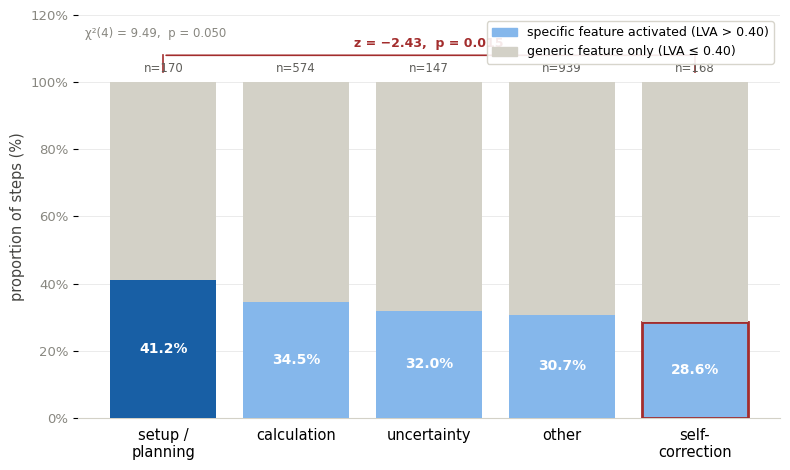

In [67]:
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import numpy as np

# ── data from your notebook ───────────────────────────────────────────────────
# rate_df already computed as: rate_df = pd.DataFrame({'total', 'specific', 'rate'})
# step_lva_spec is your 651 specific-feature steps df

rate_plot = rate_df.copy()
rate_plot['spec_pct'] = rate_plot['rate'] * 100
rate_plot['gen_pct']  = 100 - rate_plot['spec_pct']
rate_plot = rate_plot.sort_values('spec_pct', ascending=False)

step_labels = {
    'calculation': 'calculation',
    'other': 'other',
    'self_correction': 'self-\ncorrection',
    'setup_planning': 'setup /\nplanning',
    'uncertainty': 'uncertainty'
}
rate_plot.index = [step_labels[i] for i in rate_plot.index]

x = np.arange(len(rate_plot))
spec_pct = rate_plot['spec_pct'].values
gen_pct  = rate_plot['gen_pct'].values
totals   = rate_plot['total'].values

# highlight self-correction (last after sort) and setup/planning (first)
n = len(rate_plot)
spec_colors = ['#185FA5'] + ['#85B7EB'] * (n - 2) + ['#85B7EB']
edge_colors = ['#0C447C'] + ['#378ADD'] * (n - 2) + ['#A32D2D']
edge_widths = [0] + [0] * (n - 2) + [2]

# find actual positions of self_correction and setup_planning after sort
idx_setup = list(rate_plot.index).index('setup /\nplanning')
idx_selfcorr = list(rate_plot.index).index('self-\ncorrection')
spec_colors[idx_setup]    = '#185FA5';  edge_colors[idx_setup]    = '#0C447C'; edge_widths[idx_setup]    = 0
spec_colors[idx_selfcorr] = '#85B7EB'; edge_colors[idx_selfcorr] = '#A32D2D'; edge_widths[idx_selfcorr] = 2

# ── figure ────────────────────────────────────────────────────────────────────
fig, ax = plt.subplots(figsize=(8, 4.8))
fig.patch.set_facecolor('white')
ax.set_facecolor('white')

bars_spec = ax.bar(x, spec_pct, color=spec_colors,
                   edgecolor=edge_colors, linewidth=edge_widths,
                   label='specific', zorder=3)
ax.bar(x, gen_pct, bottom=spec_pct, color='#D3D1C7',
       edgecolor='none', label='generic', zorder=3)

# rate labels inside specific bars
for bar, rate in zip(bars_spec, spec_pct):
    color = 'white' if rate > 15 else '#0C447C'
    ax.text(bar.get_x() + bar.get_width() / 2, rate / 2,
            f'{rate:.1f}%', ha='center', va='center',
            fontsize=10, fontweight='bold', color=color, zorder=4)

# n= labels above bars
for xi, t in zip(x, totals):
    ax.text(xi, 102, f'n={t}', ha='center', va='bottom',
            fontsize=8.5, color='#5F5E5A')

# significance bracket between setup_planning and self_correction
bracket_y = 108
ax.annotate('', xy=(idx_selfcorr, bracket_y), xytext=(idx_setup, bracket_y),
            arrowprops=dict(arrowstyle='-', color='#A32D2D', lw=1.2))
ax.plot([idx_setup,    idx_setup],    [103, bracket_y], color='#A32D2D', lw=1.2)
ax.plot([idx_selfcorr, idx_selfcorr], [103, bracket_y], color='#A32D2D', lw=1.2)
ax.text((idx_setup + idx_selfcorr) / 2, bracket_y + 1.5,
        'z = −2.43,  p = 0.015',
        ha='center', va='bottom', fontsize=9,
        color='#A32D2D', fontweight='bold')

# axes
ax.set_xticks(x)
ax.set_xticklabels(rate_plot.index, fontsize=10.5)
ax.set_ylabel('proportion of steps (%)', fontsize=10.5, color='#444441')
ax.set_ylim(0, 120)
ax.yaxis.set_major_formatter(plt.FuncFormatter(lambda v, _: f'{int(v)}%'))
ax.tick_params(axis='y', labelcolor='#888780', labelsize=9.5)
ax.tick_params(axis='x', bottom=False)
for spine in ['top', 'right', 'left']:
    ax.spines[spine].set_visible(False)
ax.spines['bottom'].set_color('#D3D1C7')
ax.yaxis.grid(True, color='#EBEBEB', linewidth=0.7, zorder=0)
ax.set_axisbelow(True)

# legend
ax.legend(handles=[
    mpatches.Patch(color='#85B7EB', label='specific feature activated (LVA > 0.40)'),
    mpatches.Patch(color='#D3D1C7', label='generic feature only (LVA ≤ 0.40)')
], loc='upper right', fontsize=9, frameon=True, framealpha=0.9, edgecolor='#D3D1C7')

# omnibus stat
ax.text(0.01, 0.97, 'χ²(4) = 9.49,  p = 0.050',
        transform=ax.transAxes, fontsize=8.5, color='#888780', va='top')

plt.tight_layout()
plt.savefig('h2_rate_primary_finding.pdf', bbox_inches='tight', dpi=300)
plt.savefig('h2_rate_primary_finding.png', bbox_inches='tight', dpi=300)
plt.show()

H2: ALIGNMENT BY STEP TYPE
Rows in step_lva_spec 651

Descriptive stats:
                  mean    std  count  median     se   ci95
step_type                                                 
calculation      0.622  0.202    198     0.7  0.014  0.028
other            0.563  0.262    288     0.6  0.015  0.030
self_correction  0.652  0.227     48     0.7  0.033  0.064
setup_planning   0.587  0.251     70     0.6  0.030  0.059
uncertainty      0.593  0.276     47     0.6  0.040  0.079

One-way ANOVA: F = 2.489, p = 0.0422

Pairwise t-tests (Bonferroni n=10):
Pair                                                t    p_raw   p_bonf   cohen_d   sig
-------------------------------------------------------------------------------------
calculation vs self_correction                 -0.923   0.3570   1.0000    -0.144      
calculation vs uncertainty                      0.825   0.4102   1.0000     0.122      
calculation vs setup_planning                   1.161   0.2465   1.0000     0.154      
c

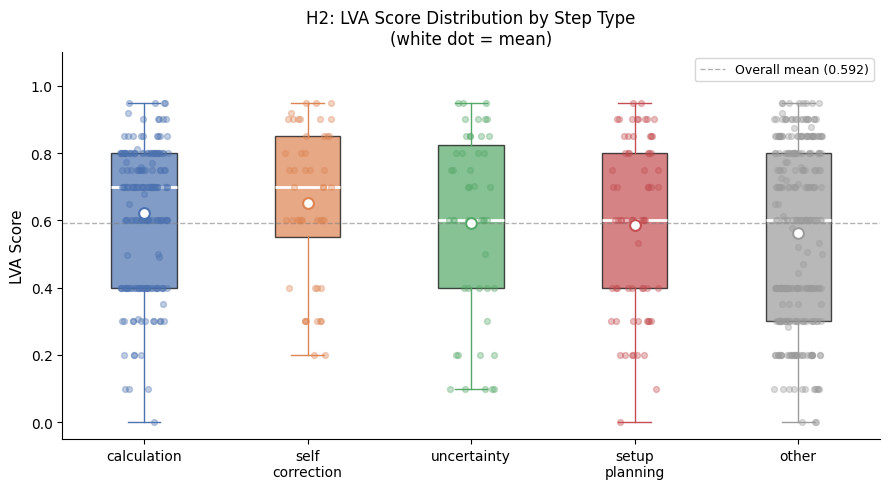

Saved: h2_step_type_lva.png

H3: SILENT FEATURES

Features with >= 3 observations: 30
5th percentile threshold (mean LVA): 0.163
Silent features (mean LVA ≤ 0.163): 2

H3 FINDING: 2 features consistently in bottom 5th percentile
  Proposal target: 15–20 features
  NOT MET — report as preliminary evidence

Silent feature list:
  feature_id   mean_lva  n_steps  feature_label
------------------------------------------------------------------------------------------
       15924      0.033        3  Geometric reasoning about circles and inscribed triangl
         582      0.133        3  Commas in mathematical explanations

Full feature score distribution (reliable features only):
count    30.000
mean      0.559
std       0.235
min       0.033
25%       0.415
50%       0.600
75%       0.750
max       0.930


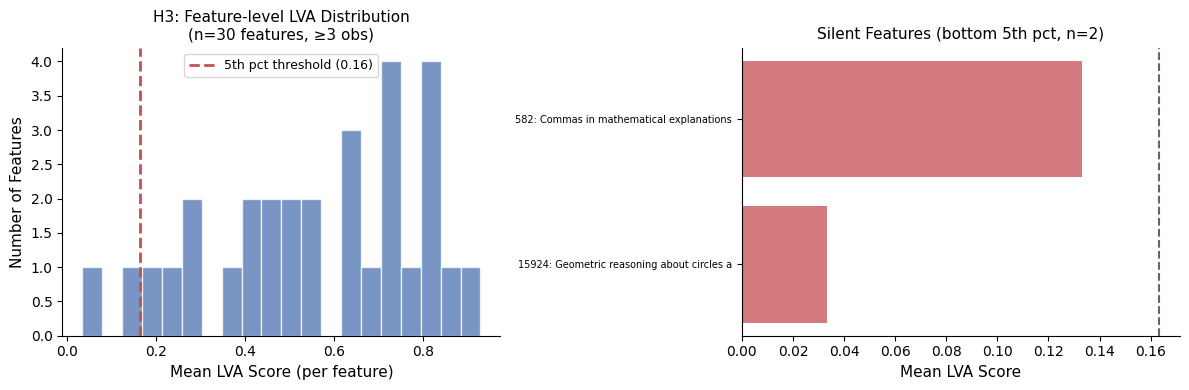

Saved: h3_silent_features.png

Silent feature appearances by step type:
                 silent_appearances  total  silent_pct
step_type                                             
other                           3.0    310         1.0
setup_planning                  1.0     72         1.4
uncertainty                     2.0     48         4.2
calculation                     0.0    210         0.0
self_correction                 0.0     48         0.0


In [58]:
# ============================================================
# H2 & H3 ANALYSIS
# ============================================================
import pandas as pd
import numpy as np
from scipy import stats
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import itertools
import warnings
warnings.filterwarnings('ignore')

# ============================================================
# H2: LVA VARIES BY STEP TYPE
# ============================================================
print("=" * 60)
print("H2: ALIGNMENT BY STEP TYPE")
print("=" * 60)

print("Rows in step_lva_spec", len(step_lva_spec))
step_types = ['calculation', 'self_correction', 'uncertainty', 'setup_planning', 'other']
groups = {st: step_lva_spec[step_lva_spec['step_type'] == st]['lva_score'].values
          for st in step_types}

# --- Descriptive stats ---
desc = step_lva_spec.groupby('step_type')['lva_score'].agg(['mean','std','count','median'])
desc['se'] = desc['std'] / np.sqrt(desc['count'])
desc['ci95'] = 1.96 * desc['se']
print("\nDescriptive stats:")
print(desc.round(3).to_string())

# --- One-way ANOVA ---
f_stat, p_anova = stats.f_oneway(*[g for g in groups.values() if len(g) > 1])
print(f"\nOne-way ANOVA: F = {f_stat:.3f}, p = {p_anova:.4f}")

# --- Pairwise t-tests (Bonferroni corrected, 10 pairs) ---
pairs = list(itertools.combinations(step_types, 2))
n_pairs = len(pairs)
print(f"\nPairwise t-tests (Bonferroni n={n_pairs}):")
print(f"{'Pair':<45} {'t':>7} {'p_raw':>8} {'p_bonf':>8} {'cohen_d':>9} {'sig':>5}")
print("-" * 85)

pairwise_results = []
for a, b in pairs:
    ga, gb = groups[a], groups[b]
    if len(ga) < 2 or len(gb) < 2:
        continue
    t, p = stats.ttest_ind(ga, gb)
    p_bonf = min(p * n_pairs, 1.0)
    # Cohen's d
    pooled_sd = np.sqrt((ga.std()**2 + gb.std()**2) / 2)
    d = (ga.mean() - gb.mean()) / pooled_sd if pooled_sd > 0 else 0
    sig = "***" if p_bonf < 0.001 else "**" if p_bonf < 0.01 else "*" if p_bonf < 0.05 else ""
    print(f"{a} vs {b:<30} {t:>7.3f} {p:>8.4f} {p_bonf:>8.4f} {d:>9.3f} {sig:>5}")
    pairwise_results.append({'pair': f"{a} vs {b}", 't': t, 'p_raw': p,
                              'p_bonf': p_bonf, 'cohen_d': d})

# --- H2 verdict ---
print(f"\nH2 FINDING:")
print(f"  Self-correction mean = {groups['self_correction'].mean():.3f} (n={len(groups['self_correction'])})")
print(f"  Calculation mean     = {groups['calculation'].mean():.3f} (n={len(groups['calculation'])})")
print(f"  Direction: self_correction {'>' if groups['self_correction'].mean() > groups['calculation'].mean() else '<'} calculation")
print(f"  NOTE: H2 predicted self_correction < calculation — observed direction is REVERSED")
print(f"  ANOVA p = {p_anova:.4f} — {'reject' if p_anova < 0.05 else 'fail to reject'} null of equal means")

# ============================================================
# H2 FIGURE: Box + strip plot by step type
# ============================================================
TYPE_ORDER = ['calculation', 'self_correction', 'uncertainty', 'setup_planning', 'other']
COLORS = {
    'calculation':    '#4C72B0',
    'self_correction':'#DD8452',
    'uncertainty':    '#55A868',
    'setup_planning': '#C44E52',
    'other':          '#9B9B9B',
}

fig, ax = plt.subplots(figsize=(9, 5))
positions = np.arange(len(TYPE_ORDER))

for i, st in enumerate(TYPE_ORDER):
    vals = groups[st]
    bp = ax.boxplot(vals, positions=[i], widths=0.4, patch_artist=True,
                    medianprops=dict(color='white', linewidth=2),
                    whiskerprops=dict(color=COLORS[st]),
                    capprops=dict(color=COLORS[st]),
                    flierprops=dict(marker='', alpha=0))
    bp['boxes'][0].set_facecolor(COLORS[st])
    bp['boxes'][0].set_alpha(0.7)
    # jitter
    jitter = np.random.default_rng(42).uniform(-0.15, 0.15, size=len(vals))
    ax.scatter(i + jitter, vals, color=COLORS[st], alpha=0.35, s=18, zorder=3)
    # mean marker
    ax.scatter(i, vals.mean(), color='white', edgecolors=COLORS[st],
               s=60, zorder=5, linewidths=1.5)

ax.set_xticks(positions)
ax.set_xticklabels([t.replace('_', '\n') for t in TYPE_ORDER], fontsize=10)
ax.set_ylabel("LVA Score", fontsize=11)
ax.set_title("H2: LVA Score Distribution by Step Type\n(white dot = mean)", fontsize=12)
ax.set_ylim(-0.05, 1.1)
ax.axhline(step_lva_spec['lva_score'].mean(), color='gray', ls='--', lw=1, alpha=0.6,
           label=f"Overall mean ({step_lva_spec['lva_score'].mean():.3f})")
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("h2_step_type_lva.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: h2_step_type_lva.png")

# ============================================================
# H3: SILENT FEATURES
# ============================================================
print("\n" + "=" * 60)
print("H3: SILENT FEATURES")
print("=" * 60)

# Per-feature stats across ALL scored pairs (use scores_specific — post generic filter)
feat_stats = (scores_specific
              .groupby(['feature_id', 'feature_label'])['lva_score']
              .agg(['mean', 'std', 'count', 'median'])
              .reset_index()
              .rename(columns={'mean': 'mean_lva', 'std': 'std_lva',
                               'count': 'n_steps', 'median': 'median_lva'}))

feat_stats['se'] = feat_stats['std_lva'] / np.sqrt(feat_stats['n_steps'])

# Threshold: bottom 5th percentile of mean_lva, among features seen >= 3 times
# (features seen only once can't be "consistently" silent)
MIN_OBS = 3
feat_reliable = feat_stats[feat_stats['n_steps'] >= MIN_OBS].copy()
threshold_5pct = feat_reliable['mean_lva'].quantile(0.05)
print(f"\nFeatures with >= {MIN_OBS} observations: {len(feat_reliable)}")
print(f"5th percentile threshold (mean LVA): {threshold_5pct:.3f}")

silent_features = feat_reliable[feat_reliable['mean_lva'] <= threshold_5pct].copy()
silent_features = silent_features.sort_values('mean_lva')

print(f"Silent features (mean LVA ≤ {threshold_5pct:.3f}): {len(silent_features)}")
print(f"\nH3 FINDING: {len(silent_features)} features consistently in bottom 5th percentile")
print(f"  Proposal target: 15–20 features")
print(f"  {'MET' if len(silent_features) >= 15 else 'NOT MET — report as preliminary evidence'}")

print(f"\nSilent feature list:")
print(f"{'feature_id':>12} {'mean_lva':>10} {'n_steps':>8}  feature_label")
print("-" * 90)
for _, row in silent_features.iterrows():
    label_trunc = row['feature_label'][:55] if isinstance(row['feature_label'], str) else ''
    print(f"{int(row['feature_id']):>12} {row['mean_lva']:>10.3f} {int(row['n_steps']):>8}  {label_trunc}")

# --- Full distribution for context ---
print(f"\nFull feature score distribution (reliable features only):")
print(feat_reliable['mean_lva'].describe().round(3).to_string())

# ============================================================
# H3 FIGURE: Feature mean LVA distribution + silent threshold
# ============================================================
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

# Left: histogram of all feature mean LVAs
ax = axes[0]
ax.hist(feat_reliable['mean_lva'], bins=20, color='#4C72B0', alpha=0.75, edgecolor='white')
ax.axvline(threshold_5pct, color='#C44E52', lw=2, ls='--',
           label=f"5th pct threshold ({threshold_5pct:.2f})")
ax.set_xlabel("Mean LVA Score (per feature)", fontsize=11)
ax.set_ylabel("Number of Features", fontsize=11)
ax.set_title(f"H3: Feature-level LVA Distribution\n(n={len(feat_reliable)} features, ≥{MIN_OBS} obs)", fontsize=11)
ax.legend(fontsize=9)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: silent features ranked, labeled
ax = axes[1]
if len(silent_features) > 0:
    y_pos = np.arange(len(silent_features))
    bars = ax.barh(y_pos, silent_features['mean_lva'], color='#C44E52', alpha=0.75)
    ax.axvline(threshold_5pct, color='black', lw=1.5, ls='--', alpha=0.6)
    short_labels = [str(int(fid)) + ': ' + (lbl[:35] if isinstance(lbl, str) else '')
                    for fid, lbl in zip(silent_features['feature_id'], silent_features['feature_label'])]
    ax.set_yticks(y_pos)
    ax.set_yticklabels(short_labels, fontsize=7)
    ax.set_xlabel("Mean LVA Score", fontsize=11)
    ax.set_title(f"Silent Features (bottom 5th pct, n={len(silent_features)})", fontsize=11)
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
else:
    ax.text(0.5, 0.5, "No silent features\nmeeting threshold",
            ha='center', va='center', transform=ax.transAxes, fontsize=12)

plt.tight_layout()
plt.savefig("h3_silent_features.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: h3_silent_features.png")

# ============================================================
# BONUS: Cross-tab silent features × step type
# (do silent features concentrate in certain step types?)
# ============================================================
if len(silent_features) > 0:
    silent_ids = set(silent_features['feature_id'])
    scores_specific['is_silent'] = scores_specific['feature_id'].isin(silent_ids)
    silent_by_type = (scores_specific[scores_specific['is_silent']]
                      .groupby('step_type')['feature_id']
                      .count()
                      .rename('silent_appearances'))
    total_by_type = scores_specific.groupby('step_type')['feature_id'].count().rename('total')
    crosstab = pd.concat([silent_by_type, total_by_type], axis=1).fillna(0)
    crosstab['silent_pct'] = (crosstab['silent_appearances'] / crosstab['total'] * 100).round(1)
    print(f"\nSilent feature appearances by step type:")
    print(crosstab.to_string())

In [76]:
reliable = scores_df_clean.groupby('feature_id')['lva_score'].agg(['mean','count'])
reliable = reliable[reliable['count'] >= 2]
threshold = reliable['mean'].quantile(0.05)
silent = reliable[reliable['mean'] <= threshold]
print(f"n features: {len(reliable)}, silent: {len(silent)}")

n features: 81, silent: 5


In [77]:
reliable_2 = scores_df_clean.groupby(['feature_id','feature_label'])['lva_score'].agg(['mean','count','std']).reset_index()
reliable_2.columns = ['feature_id','feature_label','mean_lva','n_steps','std_lva']
reliable_2 = reliable_2[reliable_2['n_steps'] >= 2].sort_values('mean_lva')
threshold_2 = reliable_2['mean_lva'].quantile(0.05)
silent_2 = reliable_2[reliable_2['mean_lva'] <= threshold_2]
print(silent_2[['feature_id','feature_label','mean_lva','n_steps']].to_string())

     feature_id                                              feature_label  mean_lva  n_steps
189       15924  Geometric reasoning about circles and inscribed triangles  0.033333        3
231       20249                             mathematical spatial reasoning  0.100000        2
339       28660             Geometric reasoning about circles and ellipses  0.100000        2
274       23364                           Commas in mathematical reasoning  0.110000       10
171       14168                           Commas in mathematical reasoning  0.120000        5


In [78]:
# get a sample step for each silent feature
for fid in [23364, 15924]:
    row = scores_df_clean[scores_df_clean['feature_id'] == fid].sort_values('lva_score').iloc[0]
    print(f"\nFeature {fid}:")
    print(f"  step: {row['step_text'][:120]}")
    print(f"  score: {row['lva_score']}")
    print(f"  reasoning: {row['reasoning']}")


Feature 23364:
  step: Wait, but x can be 0?
  score: 0.0
  reasoning: The step is a question about whether x can equal zero; it contains no commas and the label refers to punctuation usage, not the mathematical content or reasoning operation being performed.

Feature 15924:
  step: So no solution here.
  score: 0.0
  reasoning: The step is a brief conclusion about absence of solutions; the label describes geometric reasoning about circles and triangles, which are entirely absent from this step.


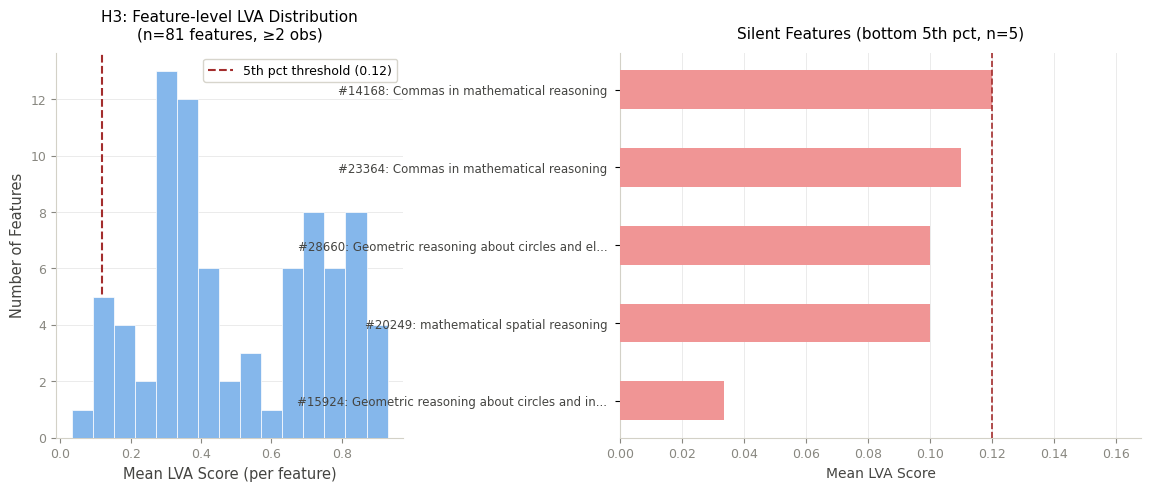

In [80]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import numpy as np

fig = plt.figure(figsize=(14, 5))
fig.patch.set_facecolor('white')
gs = gridspec.GridSpec(1, 2, width_ratios=[1.2, 1.8], wspace=0.5)

threshold = reliable_2['mean_lva'].quantile(0.05)
n_features = len(reliable_2)

def short_label(row):
    label = str(row['feature_label'])
    label = label[:40] + '...' if len(label) > 40 else label
    return f"#{int(row['feature_id'])}: {label}"

silent_2 = silent_2.copy()
silent_2['short_label'] = silent_2.apply(short_label, axis=1)

# ── left: histogram ───────────────────────────────────────────────────────────
ax1 = fig.add_subplot(gs[0])
ax1.set_facecolor('white')
ax1.hist(reliable_2['mean_lva'], bins=15, color='#85B7EB',
         edgecolor='white', linewidth=0.5, zorder=3)
ax1.axvline(threshold, color='#A32D2D', linestyle='--', linewidth=1.5,
            label=f'5th pct threshold ({threshold:.2f})')
ax1.set_xlabel('Mean LVA Score (per feature)', fontsize=10.5, color='#444441')
ax1.set_ylabel('Number of Features', fontsize=10.5, color='#444441')
ax1.set_title(f'H3: Feature-level LVA Distribution\n(n={n_features} features, ≥2 obs)',
              fontsize=11, fontweight='normal', pad=10)
ax1.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#D3D1C7')
ax1.tick_params(labelsize=9, colors='#888780')
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.spines['bottom'].set_color('#D3D1C7')
ax1.spines['left'].set_color('#D3D1C7')
ax1.yaxis.grid(True, color='#EBEBEB', linewidth=0.7, zorder=0)
ax1.set_axisbelow(True)

# ── right: silent feature bar chart ──────────────────────────────────────────
ax2 = fig.add_subplot(gs[1])
ax2.set_facecolor('white')
silent_sorted = silent_2.sort_values('mean_lva', ascending=True)
y = np.arange(len(silent_sorted))

bars = ax2.barh(y, silent_sorted['mean_lva'], color='#F09595',
                edgecolor='none', height=0.5, zorder=3)
ax2.axvline(threshold, color='#A32D2D', linestyle='--',
            linewidth=1.2, zorder=4)

# labels outside bars on the left as y-axis labels with enough margin
ax2.set_yticks(y)
ax2.set_yticklabels(silent_sorted['short_label'], fontsize=8.5,
                    color='#444441', ha='right')
ax2.set_xlabel('Mean LVA Score', fontsize=10, color='#444441')
ax2.set_title(f'Silent Features (bottom 5th pct, n={len(silent_sorted)})',
              fontsize=11, fontweight='normal', pad=10)
ax2.tick_params(axis='y', labelsize=8.5, pad=6)
ax2.tick_params(axis='x', labelsize=9, colors='#888780')

# push left margin so long labels don't get clipped
ax2.set_xlim(0, threshold * 1.4)
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.spines['bottom'].set_color('#D3D1C7')
ax2.spines['left'].set_color('#D3D1C7')
ax2.xaxis.grid(True, color='#EBEBEB', linewidth=0.7, zorder=0)
ax2.set_axisbelow(True)

plt.savefig('h3_silent_features.pdf', bbox_inches='tight', dpi=300)
plt.savefig('h3_silent_features.png', bbox_inches='tight', dpi=300)
plt.show()

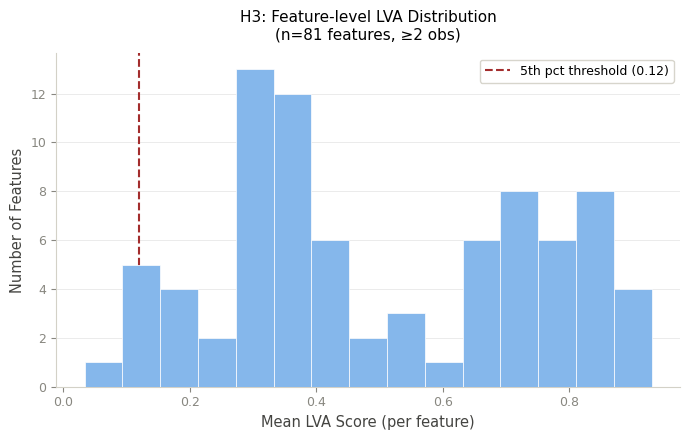

In [81]:
# ── figure 1: histogram ───────────────────────────────────────────────────────
fig1, ax1 = plt.subplots(figsize=(7, 4.5))
fig1.patch.set_facecolor('white')
ax1.set_facecolor('white')

threshold = reliable_2['mean_lva'].quantile(0.05)
n_features = len(reliable_2)

ax1.hist(reliable_2['mean_lva'], bins=15, color='#85B7EB',
         edgecolor='white', linewidth=0.5, zorder=3)
ax1.axvline(threshold, color='#A32D2D', linestyle='--', linewidth=1.5,
            label=f'5th pct threshold ({threshold:.2f})')
ax1.set_xlabel('Mean LVA Score (per feature)', fontsize=10.5, color='#444441')
ax1.set_ylabel('Number of Features', fontsize=10.5, color='#444441')
ax1.set_title(f'H3: Feature-level LVA Distribution\n(n={n_features} features, ≥2 obs)',
              fontsize=11, fontweight='normal', pad=10)
ax1.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#D3D1C7')
ax1.tick_params(labelsize=9, colors='#888780')
for spine in ['top', 'right']:
    ax1.spines[spine].set_visible(False)
ax1.spines['bottom'].set_color('#D3D1C7')
ax1.spines['left'].set_color('#D3D1C7')
ax1.yaxis.grid(True, color='#EBEBEB', linewidth=0.7, zorder=0)
ax1.set_axisbelow(True)
plt.tight_layout()
plt.savefig('h3_histogram.pdf', bbox_inches='tight', dpi=300)
plt.savefig('h3_histogram.png', bbox_inches='tight', dpi=300)
plt.show()

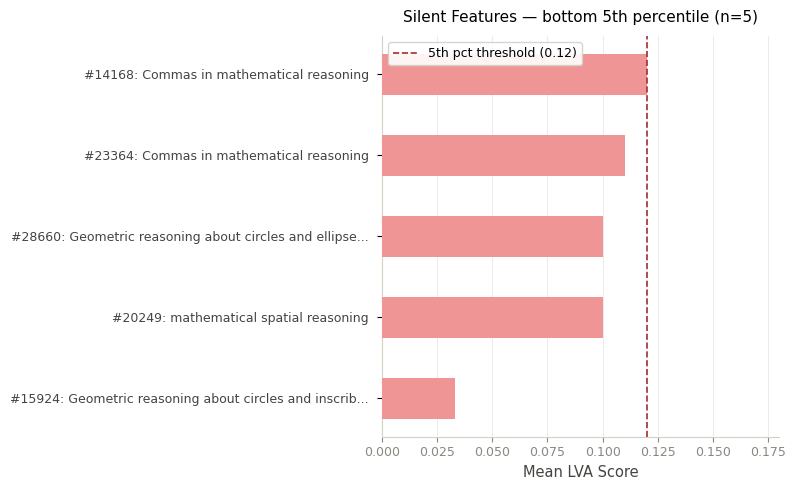

In [82]:
# ── figure 2: silent feature bar chart ───────────────────────────────────────
silent_2 = silent_2.copy()

def short_label(row):
    label = str(row['feature_label'])
    label = label[:45] + '...' if len(label) > 45 else label
    return f"#{int(row['feature_id'])}: {label}"

silent_2['short_label'] = silent_2.apply(short_label, axis=1)
silent_sorted = silent_2.sort_values('mean_lva', ascending=True)

n_silent = len(silent_sorted)
fig2, ax2 = plt.subplots(figsize=(8, max(3, n_silent * 0.7 + 1.5)))
fig2.patch.set_facecolor('white')
ax2.set_facecolor('white')

y = np.arange(n_silent)
ax2.barh(y, silent_sorted['mean_lva'], color='#F09595',
         edgecolor='none', height=0.5, zorder=3)
ax2.axvline(threshold, color='#A32D2D', linestyle='--',
            linewidth=1.2, zorder=4,
            label=f'5th pct threshold ({threshold:.2f})')

ax2.set_yticks(y)
ax2.set_yticklabels(silent_sorted['short_label'], fontsize=9, color='#444441')
ax2.set_xlabel('Mean LVA Score', fontsize=10.5, color='#444441')
ax2.set_title(f'Silent Features — bottom 5th percentile (n={n_silent})',
              fontsize=11, fontweight='normal', pad=10)
ax2.tick_params(axis='x', labelsize=9, colors='#888780')
ax2.tick_params(axis='y', labelsize=9, pad=6)
ax2.set_xlim(0, threshold * 1.5)
ax2.legend(fontsize=9, frameon=True, framealpha=0.9, edgecolor='#D3D1C7')
for spine in ['top', 'right']:
    ax2.spines[spine].set_visible(False)
ax2.spines['bottom'].set_color('#D3D1C7')
ax2.spines['left'].set_color('#D3D1C7')
ax2.xaxis.grid(True, color='#EBEBEB', linewidth=0.7, zorder=0)
ax2.set_axisbelow(True)
plt.tight_layout()
plt.savefig('h3_silent_bar.pdf', bbox_inches='tight', dpi=300)
plt.savefig('h3_silent_bar.png', bbox_inches='tight', dpi=300)
plt.show()

In [72]:

step_feat_df = pd.read_parquet(CACHE_DIR / "step_feat_df_step1_maxpool_k3_lnorm.parquet")

In [83]:
len(step_feat_df)

64554

In [84]:
# full pre-sampling df — just needs sequence_id, step_idx, feature_id, strength, step_type
X_df = step_feat_df.pivot_table(
    index=['sequence_id', 'step_idx'],
    columns='feature_id',
    values='strength',
    fill_value=0
)

labels = step_feat_df.drop_duplicates(
    subset=['sequence_id', 'step_idx']
).set_index(['sequence_id', 'step_idx'])['step_type']

X = X_df.values
y = labels.loc[X_df.index].values

print(f"X shape: {X.shape}")
print(f"Class distribution: {pd.Series(y).value_counts()}")

X shape: (21518, 1498)
Class distribution: other              10112
calculation         6180
setup_planning      1829
self_correction     1805
uncertainty         1592
Name: count, dtype: int64


In [85]:
from sklearn.linear_model import LogisticRegression
from sklearn.model_selection import cross_val_score, StratifiedKFold
from sklearn.preprocessing import LabelEncoder
import numpy as np

le = LabelEncoder()
y_enc = le.fit_transform(y)

# chance baseline = majority class proportion
chance = pd.Series(y).value_counts(normalize=True).max()
print(f"Chance baseline (majority class): {chance:.3f}")

# 5-fold stratified cross-validation
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=42)
clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs', 
                         multi_class='multinomial', n_jobs=-1)

scores = cross_val_score(clf, X, y_enc, cv=cv, scoring='accuracy')
print(f"\nProbe accuracy: {scores.mean():.3f} ± {scores.std():.3f}")
print(f"Chance baseline: {chance:.3f}")
print(f"Lift over chance: {scores.mean() - chance:.3f}")

# per-class breakdown
from sklearn.model_selection import cross_val_predict
from sklearn.metrics import classification_report

y_pred = cross_val_predict(clf, X, y_enc, cv=cv)
print("\nPer-class report:")
print(classification_report(y_enc, y_pred, 
      target_names=le.classes_))

Chance baseline (majority class): 0.470

Probe accuracy: 0.553 ± 0.005
Chance baseline: 0.470
Lift over chance: 0.083

Per-class report:
                 precision    recall  f1-score   support

    calculation       0.57      0.53      0.55      6180
          other       0.55      0.79      0.65     10112
self_correction       0.55      0.13      0.21      1805
 setup_planning       0.45      0.10      0.17      1829
    uncertainty       0.44      0.12      0.18      1592

       accuracy                           0.55     21518
      macro avg       0.51      0.33      0.35     21518
   weighted avg       0.54      0.55      0.51     21518



In [73]:
# use your full pre-sampling dataframe (64,554 rows, no lva scores needed)
silent_ids = [23364, 14168, 15924, 28660, 20249]

full_activation_counts = step_feat_df[step_feat_df['feature_id'].isin(silent_ids)].groupby('feature_id').agg(
    n_steps=('step_idx','count'),
    n_sequences=('sequence_id','nunique'),
    mean_strength=('strength','mean')
).reset_index()

print(full_activation_counts.to_string())

   feature_id  n_steps  n_sequences  mean_strength
0       14168       30           21       1.459635
1       15924       13           12       1.526442
2       20249       23           16       1.657609
3       23364       77           43       1.576096
4       28660       13            7       2.043269


In [75]:
silent_ids = [23364, 15924]

for fid in silent_ids:
    rows = scores_df_clean[scores_df_clean['feature_id'] == fid].sort_values('lva_score')
    print(f"\nFeature {fid} — {rows.iloc[0]['feature_label']}")
    print(f"n scored: {len(rows)}, mean LVA: {rows['lva_score'].mean():.3f}")
    for _, row in rows.head(3).iterrows():
        print(f"  score={row['lva_score']} | step: {row['step_text'][:100]}")
        print(f"  reasoning: {row['reasoning'][:120]}")


Feature 23364 — Commas in mathematical reasoning
n scored: 10, mean LVA: 0.110
  score=0.0 | step: Wait, but x can be 0?
  reasoning: The step is a question about whether x can equal zero; it contains no commas and the label refers to punctuation usage, 
  score=0.0 | step: Wait, that's too big.
  reasoning: This step contains no commas and involves no mathematical reasoning—it's a brief, colloquial objection with no mathemati
  score=0.1 | step: Wait, no, they are contiguous.
  reasoning: This step is a brief self-correction about contiguity with no mathematical content, commas, or formal reasoning structur

Feature 15924 — Geometric reasoning about circles and inscribed triangles
n scored: 3, mean LVA: 0.033
  score=0.0 | step: So no solution here.
  reasoning: The step is a brief conclusion about absence of solutions; the label describes geometric reasoning about circles and tri
  score=0.0 | step: Therefore, if we add 13 to the subset, we need to exclude 36.
  reasoning: The step 

In [52]:
# How many unique features appear in scores_df (unfiltered)?
print(scores_df_clean['feature_id'].nunique())
print(scores_df_clean.groupby('feature_id').size().describe())

# And specifically: how many features have >= 10 observations in scores_df?
print((scores_df_clean.groupby('feature_id').size() >= 10).sum())

340
count     340.000000
mean       17.626471
std       136.115121
min         1.000000
25%         1.000000
50%         1.000000
75%         1.000000
max      1994.000000
dtype: float64
21


In [53]:
# H3 on full scores_df, relaxed to >= 10 obs
feat_stats_full = (scores_df_clean
    .groupby(['feature_id', 'feature_label'])['lva_score']
    .agg(['mean', 'std', 'count', 'median'])
    .reset_index()
    .rename(columns={'mean':'mean_lva','std':'std_lva',
                     'count':'n_steps','median':'median_lva'}))

feat_reliable_full = feat_stats_full[feat_stats_full['n_steps'] >= 10].copy()
print(f"Features with >= 10 obs: {len(feat_reliable_full)}")
print(feat_reliable_full.sort_values('mean_lva')[['feature_id','feature_label',
                                                   'mean_lva','n_steps']].to_string())

threshold = feat_reliable_full['mean_lva'].quantile(0.05)
silent = feat_reliable_full[feat_reliable_full['mean_lva'] <= threshold]
print(f"\nThreshold: {threshold:.3f}")
print(f"Silent features: {len(silent)}")

Features with >= 10 obs: 21
     feature_id                                                           feature_label  mean_lva  n_steps
274       23364                                        Commas in mathematical reasoning  0.110000       10
44         3690        Mathematical reasoning with prime numbers and divisibility tests  0.154386      228
127       10219  Mathematical word problems requiring calculation and logical reasoning  0.277128       94
10         1316                                               Geometric problem solving  0.310417       24
327       28257                            Mathematical problem-solving and calculation  0.315000       20
252       21818                        Unfinished mathematical problem-solving attempts  0.324101      278
128       10274                               Mathematical problem-solving and counting  0.325388      258
42         3477                                  Mathematical reasoning and calculation  0.327083       24
264      

In [54]:
top_features = (scores_df_clean.groupby(['feature_id','feature_label'])
                .size().reset_index(name='n')
                .sort_values('n', ascending=False).head(10))
print(top_features.to_string())

     feature_id                                                           feature_label     n
181       15072                 Mathematical reasoning and step-by-step problem solving  1994
310       26742                       Mathematical problem-solving with formal notation  1340
46         3877              Mathematical problem-solving and step-by-step calculations   470
93         7464             Mathematical expressions involving variables and operations   369
252       21818                        Unfinished mathematical problem-solving attempts   278
128       10274                               Mathematical problem-solving and counting   258
44         3690        Mathematical reasoning with prime numbers and divisibility tests   228
269       22964                                  Step-by-step mathematical calculations   206
127       10219  Mathematical word problems requiring calculation and logical reasoning    94
63         5265                                  Mathematica

In [55]:
# Inspect feature 3690's worst-scoring appearances
feat_3690 = scores_df_clean[scores_df_clean['feature_id'] == 3690].sort_values('lva_score')
print(feat_3690[['step_text','lva_score','reasoning']].head(10).to_string())

# And its best-scoring, for contrast
print(feat_3690[['step_text','lva_score','reasoning']].tail(5).to_string())

                                                                                                                                                                                             step_text  lva_score                                                                                                                                                                                         reasoning
28                                                                                                                                                             B is μ_k Mg, which is kinetic friction.        0.0             The step involves identifying a physics quantity (kinetic friction) through symbolic substitution, with no involvement of prime numbers, divisibility, or number-theoretic reasoning.
306                                                                                                                                                                            Vector DF is (0, 

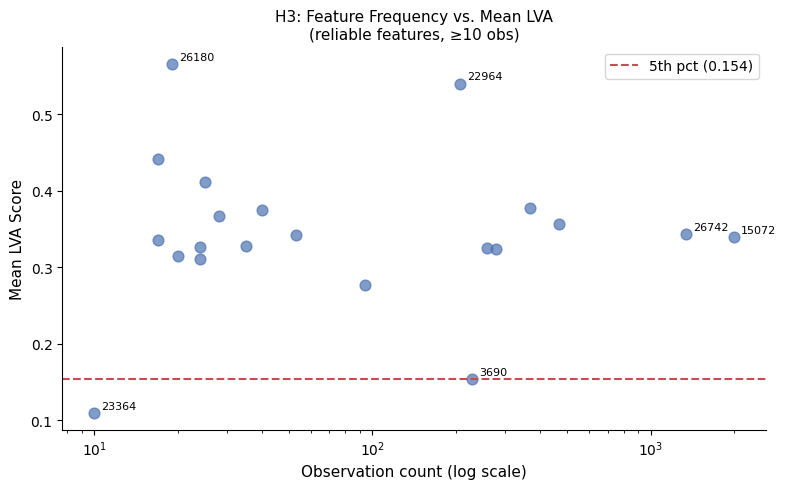

In [56]:
fig, ax = plt.subplots(figsize=(8, 5))
ax.scatter(feat_reliable_full['n_steps'], feat_reliable_full['mean_lva'],
           color='#4C72B0', alpha=0.7, s=60)

# Annotate silent + high-frequency features
highlight_ids = {23364, 3690, 15072, 26742, 22964, 26180}
for _, row in feat_reliable_full.iterrows():
    if row['feature_id'] in highlight_ids:
        ax.annotate(f"{int(row['feature_id'])}", 
                    (row['n_steps'], row['mean_lva']),
                    textcoords='offset points', xytext=(5, 3), fontsize=8)

ax.axhline(threshold, color='#C44E52', ls='--', lw=1.5,
           label=f"5th pct ({threshold:.3f})")
ax.set_xscale('log')
ax.set_xlabel("Observation count (log scale)", fontsize=11)
ax.set_ylabel("Mean LVA Score", fontsize=11)
ax.set_title("H3: Feature Frequency vs. Mean LVA\n(reliable features, ≥10 obs)", fontsize=11)
ax.legend(); ax.spines['top'].set_visible(False); ax.spines['right'].set_visible(False)
plt.tight_layout()
plt.savefig("h3_frequency_vs_lva.png", dpi=150, bbox_inches='tight')
plt.show()

In [57]:
feat_3690 = scores_df_clean[scores_df_clean['feature_id'] == 3690].sort_values('lva_score')
print("=== LOWEST SCORING (potential silent) ===")
pd.set_option('display.max_colwidth', 80)
print(feat_3690[['step_text', 'lva_score', 'reasoning']].head(10).to_string())

print("\n=== HIGHEST SCORING (when does it align?) ===")
print(feat_3690[['step_text', 'lva_score', 'reasoning']].tail(5).to_string())

print("\n=== SCORE DISTRIBUTION ===")
print(feat_3690['lva_score'].value_counts().sort_index())
print(f"\nProportion scoring <= 0.2: {(feat_3690['lva_score'] <= 0.2).mean():.2f}")
print(f"Proportion scoring >= 0.7: {(feat_3690['lva_score'] >= 0.7).mean():.2f}")

=== LOWEST SCORING (potential silent) ===
                                                                                                                                                                                             step_text  lva_score                                                                                                                                                                                         reasoning
28                                                                                                                                                             B is μ_k Mg, which is kinetic friction.        0.0             The step involves identifying a physics quantity (kinetic friction) through symbolic substitution, with no involvement of prime numbers, divisibility, or number-theoretic reasoning.
306                                                                                                                                                   

In [18]:
import numpy as np

# Get step-level scores for both
real_scores = matched["lva_score"].values
shuf_scores = matched["lva_score_shuffled"].values

bins = np.arange(0, 1.1, 0.1)
real_hist, _ = np.histogram(real_scores, bins=bins, density=False)
shuf_hist, _ = np.histogram(shuf_scores, bins=bins, density=False)

# Convert to percentage
real_pct = 100 * real_hist / len(real_scores)
shuf_pct = 100 * shuf_hist / len(shuf_scores)

print("Bin     Real%   Shuffled%")
for i, (r, s) in enumerate(zip(real_pct, shuf_pct)):
    print(f"{bins[i]:.1f}-{bins[i+1]:.1f}  {r:.1f}%    {s:.1f}%")

Bin     Real%   Shuffled%
0.0-0.1  0.8%    4.5%
0.1-0.2  3.0%    18.2%
0.2-0.3  15.4%    36.0%
0.3-0.4  1.0%    1.3%
0.4-0.5  15.7%    16.2%
0.5-0.6  14.6%    9.6%
0.6-0.7  11.7%    5.6%
0.7-0.8  7.7%    3.0%
0.8-0.9  20.5%    3.8%
0.9-1.0  9.8%    1.8%


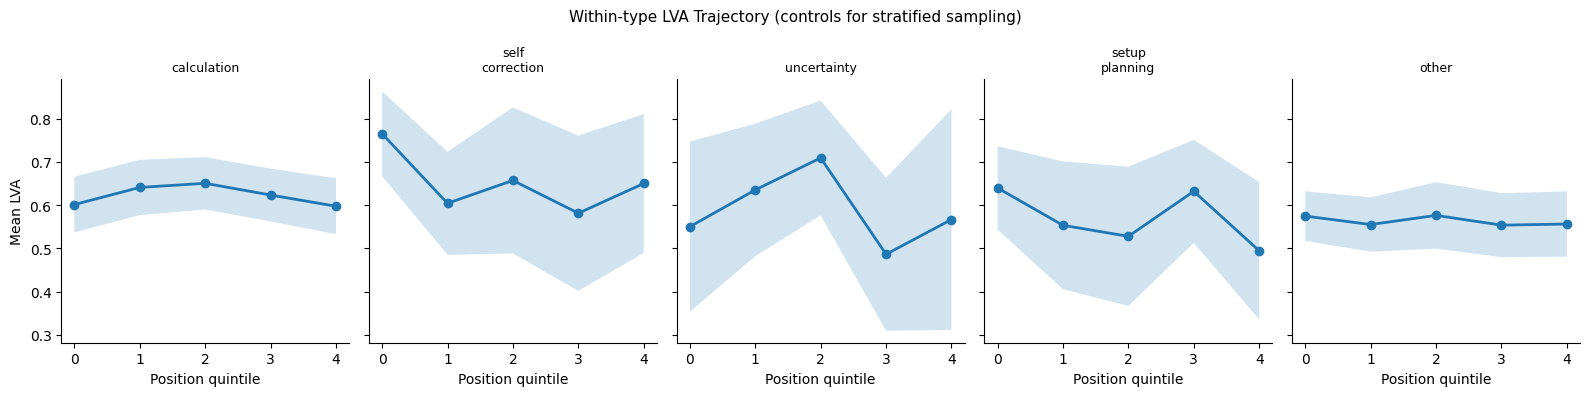

In [58]:
fig, axes = plt.subplots(1, 5, figsize=(16, 4), sharey=True)
for ax, st in zip(axes, ['calculation','self_correction','uncertainty','setup_planning','other']):
    sub = step_lva_spec[step_lva_spec['step_type'] == st].copy()
    sub['pos_bin'] = pd.cut(sub['rel_step_pos'], bins=5, labels=False)
    traj = sub.groupby('pos_bin')['lva_score'].agg(['mean','sem','count']).reset_index()
    ax.plot(traj['pos_bin'], traj['mean'], 'o-', lw=2)
    ax.fill_between(traj['pos_bin'],
                    traj['mean'] - 1.96*traj['sem'],
                    traj['mean'] + 1.96*traj['sem'], alpha=0.2)
    ax.set_title(st.replace('_','\n'), fontsize=9)
    ax.set_xlabel("Position quintile")
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
axes[0].set_ylabel("Mean LVA")
plt.suptitle("Within-type LVA Trajectory (controls for stratified sampling)", fontsize=11)
plt.tight_layout()
plt.savefig("trajectory_by_type.png", dpi=150, bbox_inches='tight')
plt.show()

In [60]:
# What does your activations data look like?
print(scores_df_clean.columns.tolist())
# or whatever your raw pre-scoring dataframe is called

# Specifically - is the full SAE feature vector stored,
# or just the top-k active features + their strengths?
print(scores_df_clean.head(3))

['sequence_id', 'step_idx', 'rel_step_pos', 'step_type', 'feature_id', 'feature_label', 'feature_rank', 'strength', 'strength_w', 'lva_score', 'confidence', 'reasoning', 'step_text']
   sequence_id  step_idx  rel_step_pos        step_type  feature_id  \
0         1000        22      0.153846  self_correction       15072   
1         1000         5      0.034965   setup_planning       26742   
2         1000         5      0.034965   setup_planning        3477   

                                             feature_label  feature_rank  \
0  Mathematical reasoning and step-by-step problem solving             1   
1        Mathematical problem-solving with formal notation             3   
2                   Mathematical reasoning and calculation             2   

   strength  strength_w  lva_score confidence  \
0  3.312500    0.418559        0.2       high   
1  2.125000    0.272000        0.2       high   
2  2.203125    0.282000        0.3       high   

                              

Matrix shape: 1998 steps × 340 features
Step type classes: ['calculation' 'other' 'self_correction' 'setup_planning' 'uncertainty']
Class distribution: {'calculation': np.int64(574), 'other': np.int64(939), 'self_correction': np.int64(168), 'setup_planning': np.int64(170), 'uncertainty': np.int64(147)}

Train: 1524 steps | Test: 474 steps

PROBE A: Activations → Step Type
                 precision    recall  f1-score   support

    calculation       0.53      0.52      0.53       130
          other       0.58      0.79      0.67       241
self_correction       0.33      0.05      0.09        37
 setup_planning       0.75      0.10      0.18        30
    uncertainty       0.38      0.08      0.14        36

       accuracy                           0.56       474
      macro avg       0.51      0.31      0.32       474
   weighted avg       0.54      0.56      0.51       474

Macro F1: 0.321
Weighted F1: 0.515
Chance (majority) macro F1: 0.135
Permutation baseline macro F1: 0.148 ± 0

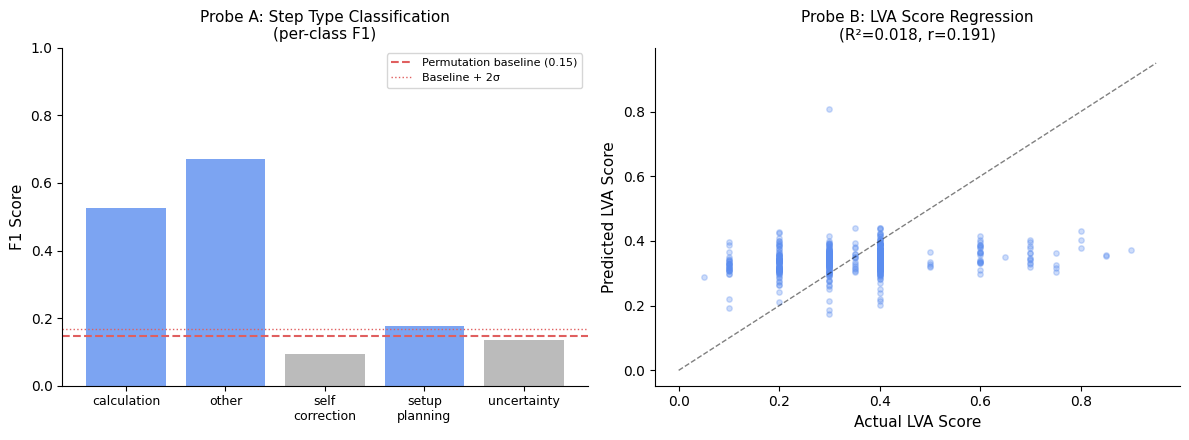

Saved: linear_probe.png


In [61]:
# ============================================================
# LINEAR PROBE: SAE Feature Activations → Step Type / LVA
# ============================================================
import numpy as np
import pandas as pd
from scipy.sparse import csr_matrix
from sklearn.linear_model import LogisticRegression, Ridge
from sklearn.model_selection import GroupShuffleSplit
from sklearn.preprocessing import LabelEncoder
from sklearn.metrics import classification_report, r2_score, f1_score
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# ── 1. Build sparse feature matrix ───────────────────────────
# One row per (sequence_id, step_idx), one column per feature_id
# Value = activation strength at that step

# Use scores_specific (post-generic-filter) for consistency with H1-H3
# but scores_df (full) gives more signal — try full first
df = scores_df_clean.copy()  # 5,993 pairs

# Step index: unique (sequence_id, step_idx) pairs
step_keys = (df[['sequence_id','step_idx','step_type','lva_score','rel_step_pos']]
             .drop_duplicates(['sequence_id','step_idx'])
             .reset_index(drop=True))
step_keys['step_row'] = np.arange(len(step_keys))

df = df.merge(step_keys[['sequence_id','step_idx','step_row']],
              on=['sequence_id','step_idx'])

# Feature column index
all_feature_ids = sorted(df['feature_id'].unique())
feat_to_col = {fid: i for i, fid in enumerate(all_feature_ids)}
n_steps = len(step_keys)
n_feats = len(all_feature_ids)
print(f"Matrix shape: {n_steps} steps × {n_feats} features")

rows = df['step_row'].values
cols = df['feature_id'].map(feat_to_col).values
vals = df['strength'].values  # use raw activation strength

X_sparse = csr_matrix((vals, (rows, cols)), shape=(n_steps, n_feats))

# ── 2. Targets ────────────────────────────────────────────────
le = LabelEncoder()
y_type = le.fit_transform(step_keys['step_type'])   # step type classification
y_lva  = step_keys['lva_score'].values              # LVA regression
groups = step_keys['sequence_id'].values            # for group split

print(f"Step type classes: {le.classes_}")
print(f"Class distribution: {dict(zip(le.classes_, np.bincount(y_type)))}")

# ── 3. Train/test split by sequence_id (no leakage) ──────────
gss = GroupShuffleSplit(n_splits=1, test_size=0.2, random_state=42)
train_idx, test_idx = next(gss.split(X_sparse, y_type, groups=groups))

X_train, X_test = X_sparse[train_idx], X_sparse[test_idx]
yt_train, yt_test = y_type[train_idx], y_type[test_idx]
yl_train, yl_test = y_lva[train_idx], y_lva[test_idx]

print(f"\nTrain: {len(train_idx)} steps | Test: {len(test_idx)} steps")

# ── 4. Probe A: Step type classification ─────────────────────
print("\n" + "="*50)
print("PROBE A: Activations → Step Type")
print("="*50)

clf = LogisticRegression(max_iter=1000, C=1.0, solver='lbfgs',
                         multi_class='multinomial', random_state=42)
clf.fit(X_train, yt_train)
y_pred = clf.predict(X_test)

print(classification_report(yt_test, y_pred, target_names=le.classes_))

# Macro F1
f1_macro = f1_score(yt_test, y_pred, average='macro')
f1_weighted = f1_score(yt_test, y_pred, average='weighted')
print(f"Macro F1: {f1_macro:.3f}")
print(f"Weighted F1: {f1_weighted:.3f}")

# Chance baseline: majority class
majority_pred = np.full_like(yt_test, np.bincount(yt_train).argmax())
f1_chance = f1_score(yt_test, majority_pred, average='macro')
print(f"Chance (majority) macro F1: {f1_chance:.3f}")

# Permutation baseline
from sklearn.utils import shuffle as sk_shuffle
perm_f1s = []
for _ in range(100):
    yt_perm = sk_shuffle(yt_train, random_state=None)
    clf_perm = LogisticRegression(max_iter=500, C=1.0, solver='lbfgs',
                                   multi_class='multinomial', random_state=42)
    clf_perm.fit(X_train, yt_perm)
    perm_f1s.append(f1_score(yt_test, clf_perm.predict(X_test), average='macro'))
perm_mean = np.mean(perm_f1s)
perm_std  = np.std(perm_f1s)
print(f"Permutation baseline macro F1: {perm_mean:.3f} ± {perm_std:.3f}")
print(f"Above permutation: {f1_macro > perm_mean + 2*perm_std}")

# ── 5. Probe B: LVA score regression ─────────────────────────
print("\n" + "="*50)
print("PROBE B: Activations → LVA Score")
print("="*50)

reg = Ridge(alpha=1.0)
reg.fit(X_train, yl_train)
yl_pred = reg.predict(X_test)

r2 = r2_score(yl_test, yl_pred)
corr = np.corrcoef(yl_test, yl_pred)[0,1]
print(f"R² = {r2:.3f}")
print(f"Pearson r (predicted vs actual) = {corr:.3f}")

# Baseline: predict mean
yl_mean_pred = np.full_like(yl_test, yl_train.mean())
r2_baseline = r2_score(yl_test, yl_mean_pred)
print(f"Baseline R² (predict mean) = {r2_baseline:.3f}")

# ── 6. Top predictive features per step type ─────────────────
print("\n" + "="*50)
print("TOP FEATURES PER STEP TYPE (Probe A coefficients)")
print("="*50)
feat_id_arr = np.array(all_feature_ids)
# Map feature_id → label
fid_to_label = df.drop_duplicates('feature_id').set_index('feature_id')['feature_label'].to_dict()

for i, cls in enumerate(le.classes_):
    coefs = clf.coef_[i]
    top_pos = np.argsort(coefs)[-3:][::-1]
    top_neg = np.argsort(coefs)[:3]
    print(f"\n{cls}:")
    print("  Positive (predicts this type):")
    for idx in top_pos:
        fid = feat_id_arr[idx]
        print(f"    feat {fid} (coef={coefs[idx]:.3f}): {fid_to_label.get(fid,'?')[:60]}")
    print("  Negative (predicts away):")
    for idx in top_neg:
        fid = feat_id_arr[idx]
        print(f"    feat {fid} (coef={coefs[idx]:.3f}): {fid_to_label.get(fid,'?')[:60]}")

# ── 7. FIGURE ─────────────────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(12, 4.5))

# Left: per-class F1 bar chart
ax = axes[0]
report = classification_report(yt_test, y_pred,
                                target_names=le.classes_, output_dict=True)
classes = le.classes_
f1s = [report[c]['f1-score'] for c in classes]
colors = ['#5B8DEF' if f > perm_mean + 2*perm_std else '#AAAAAA' for f in f1s]
bars = ax.bar(classes, f1s, color=colors, alpha=0.8)
ax.axhline(perm_mean, color='#E05F5F', ls='--', lw=1.5,
           label=f'Permutation baseline ({perm_mean:.2f})')
ax.axhline(perm_mean + 2*perm_std, color='#E05F5F', ls=':', lw=1,
           label='Baseline + 2σ')
ax.set_ylim(0, 1)
ax.set_ylabel("F1 Score", fontsize=11)
ax.set_title("Probe A: Step Type Classification\n(per-class F1)", fontsize=11)
ax.set_xticklabels([c.replace('_','\n') for c in classes], fontsize=9)
ax.legend(fontsize=8)
ax.spines['top'].set_visible(False)
ax.spines['right'].set_visible(False)

# Right: predicted vs actual LVA scatter
ax2 = axes[1]
ax2.scatter(yl_test, yl_pred, alpha=0.3, s=15, color='#5B8DEF')
lims = [min(yl_test.min(), yl_pred.min()) - 0.05,
        max(yl_test.max(), yl_pred.max()) + 0.05]
ax2.plot(lims, lims, 'k--', lw=1, alpha=0.5)
ax2.set_xlabel("Actual LVA Score", fontsize=11)
ax2.set_ylabel("Predicted LVA Score", fontsize=11)
ax2.set_title(f"Probe B: LVA Score Regression\n(R²={r2:.3f}, r={corr:.3f})", fontsize=11)
ax2.spines['top'].set_visible(False)
ax2.spines['right'].set_visible(False)

plt.tight_layout()
plt.savefig("linear_probe.png", dpi=150, bbox_inches='tight')
plt.show()
print("Saved: linear_probe.png")